Selección y Armonización de Datos

1. Seleccionar datasets textuales etiquetados con licencia clara y tamaño >1GB.
2. Unificar el esquema de columnas de los datos (text, label).
3. Normalizar la taxonomía de etiquetas utilizando mapas de etiquetas.
4. Deduplicar textos para evitar la fuga de información entre train y test.
5. Controlar el desbalance de clases usando pesos por clase o sampling si es necesario.

Tarea Técnica: Modelado y Evaluación

6. Diseñar un pipeline de PLN de extremo a extremo para clasificación multiclase.
7. Implementar baselines clásicos como TF-IDF (+ BoW) con regresión logística o SVM lineal.
8. Realizar validación con CV o partición train/val/test, siempre con estratificación.
9. Reportar las métricas Accuracy, F1-Macro (obligatoria), F1 por clase y la matriz de confusión.
10. Comparar las representaciones clásicas (BoW/TF-IDF) con modelos Transformer.
11. Realizar fine-tuning de un modelo Transformer (BERT/RoBERTa).
12. Definir y reportar hiperparámetros y condiciones de entrenamiento (semillas, batch size, lr, épocas).

Explicabilidad y Análisis de Errores

13. Aplicar explicabilidad local a 20 ejemplos (10 aciertos + 10 errores).
14. Usar para los modelos clásicos top n-grams/coeficientes o SHAP/LIME sobre TF-IDF.
15. Emplear para los Transformer métodos como Integrated Gradients o atribución sobre atención (con cautela).
16. Mostrar fragmentos textuales resaltados (rationales) y una breve justificación de la etiqueta elegida.
17. Analizar los errores típicos (FP/FN) y en subgrupos específicos (longitud, mayúsculas, URLs).
18. Proponer medidas de mitigación para los errores encontrados.

Reproducibilidad y Entrega

19. Garantizar la reproducibilidad fijando semillas.
20. Listar dependencias en un requirements.txt o environment.yml.
21. Crear scripts train.py y eval.py, y guardar el mejor checkpoint (best.ckpt) y configuración (config.json).
22. Comunicar los resultados claramente en un Informe.pdf (8–12 páginas).
23. Incluir un README.md con los pasos exactos para reproducir todos los resultados y tablas.

## 0.1 Seleccionar Datasets

Nos centramos en desarrollar la práctica sobre la identificación de géneros musicales a partir de las letras de las canciones (etiquetadas como _lyrics_ en nuestros datasets). Encontramos los datasets buscando por internet y HuggingFace, encontrando uno a través del siguiente enlace: https://data.mendeley.com/datasets/3t9vbwxgr5/2 y el otro en HuggingFace en este enlace: https://www.kaggle.com/datasets/carlosgdcj/genius-song-lyrics-with-language-information/data.

Pero investigando un poco más descubrimos que el primero se encotraba también en HuggingFace, lo que nos simplificó la descarga de los datos, que ahora se consiguen llamando a la función `download_datasets()` de `src/utils/io.py`.

In [19]:
from src.utils.io import DatasetManager

dm = DatasetManager()
dm.download(df1=True, df2=False, df3=False)

Directorio de destino deseado para CSVs: C:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\PLN2\Practicas\practica1\pln2_practica1\data

Descargando saurabhshahane/music-dataset-1950-to-2019...


100%|██████████| 9.73M/9.73M [00:01<00:00, 9.67MB/s]

Extracting files...


Descarga inicial completada en: C:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\PLN2\Practicas\practica1\pln2_practica1\data\datasets\saurabhshahane\music-dataset-1950-to-2019\versions\3
Moviendo 'tcc_ceds_music.csv' a 'C:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\PLN2\Practicas\practica1\pln2_practica1\data\tcc_ceds_music.csv'...
Error al descargar o procesar saurabhshahane/music-dataset-1950-to-2019: [Errno 22] Invalid argument: 'C:\\Users\\diego\\OneDrive - Universidad Rey Juan Carlos\\Documentos\\GIA_URJC\\Curso 2025-26\\PLN2\\Practicas\\practica1\\pln2_practica1\\data\\tcc_ceds_music.csv'

Limpiando directorio de caché de kagglehub: C:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\PLN2\Practicas\practica1\pln2_practica1\data\datasets
Limpieza completada.


## 0.2 Cargamos el dataset `song_lyrics.csv` filtramos por `en`

In [20]:
df = dm.load("song_lyrics.csv")

`HAY QUE MODIFICAR ESTE CÓDIGO PARA QUE APAREZCA BONITO Y ELIMINAR EL ERROR DE LA CELDA DE ABAJO`

In [22]:
# Filtrar únicamente las filas donde 'languaje' == 'en'
df_filtrado = df[df["language"] == "en"]

# Guardar el dataset en el directorio /data
# dm.save_dataset(df_filtrado, "en_song_lyrics.csv") # Sale el error de que la función no existe

# Guarda los datos en vez de usar la función de arriba
df_filtrado.to_csv("en_song_lyrics.csv", index=False)

## 1. SELECCIÓN Y ARMONIZACIÓN DE DATOS:

In [1]:
from src.utils.preprocesing import DataProcessor

dp = DataProcessor()

# Ejecutar pipeline
dp.load_and_unify("en_song_lyrics.csv") # Puntos 1 y 2
dp.normalize_labels()                   # Punto 3
dp.clean_and_deduplicate()              # Punto 4
dp.handle_imbalance()                   # Punto 5

c:\Users\diego\miniconda3\envs\pln2_p1_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Directorio de destino deseado para CSVs: C:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\PLN2\Practicas\practica1\pln2_practica1\data
Dataset cargado: (3374198, 11)
No hay filas con valores desconocidos.
Asignando IDs numéricos: {'country': 0, 'misc': 1, 'pop': 2, 'rap': 3, 'rb': 4, 'rock': 5}
Clases resultantes: [3 4 5 2 1 0]

Limpiando y deduplicando...
--> Filas eliminadas: 57958
--> Dataset limpio: 3316240

Gestionando desbalance de clases...
Distribución original:
label
2    1351040
3     962228
5     626779
4     154242
1     136030
0      85921
Name: count, dtype: int64

Distribución tras balanceo estricto:
label
0    85921
5    85921
1    85921
4    85921
2    85921
3    85921
Name: count, dtype: int64


Guardamos el dataset limpio para no gastar tiempo repitiendo este proceso luego:

In [2]:
dp.save(filename="en_song_lyrics_clear.csv")

Guardando dataset filtrado en: C:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\PLN2\Practicas\practica1\pln2_practica1\data\en_song_lyrics_clear.csv...
Archivo guardado correctamente.


## 2. Tarea técnica: Modelado y validación

Explicación de los parámetros usados en la vectorización:

1. `max_features=20000 (Control de Dimensionalidad)`
    - El problema: El vocabulario en un corpus de 500.000 canciones es inmenso. Si cuentas todas las palabras únicas (incluyendo erratas o nombres propios raros), podrías tener 200.000 o 300.000 columnas. Esto haría que el entrenamiento fuera lentísimo y consumiría toda tu memoria RAM.
    - La solución: Le decimos al modelo: "Quédate solo con las 20.000 palabras más frecuentes e importantes; ignora el resto".
    - Por qué 20k: Es un sweet spot (punto dulce). Captura suficiente vocabulario para diferenciar géneros sin incluir el "ruido" de palabras que solo aparecen una vez en todo el dataset (que suelen llevar a sobreajuste).
    
2. `ngram_range=(1, 2) (Contexto)`
    - El problema: Si usamos solo palabras sueltas (unigramas), perdemos el contexto.
    - Ejemplo: La palabra "Heavy" por sí sola no dice mucho.La palabra "Metal" por sí sola puede ser un material.
    - La solución: Al poner (1, 2), el modelo analiza unigramas (palabras sueltas) Y bigramas (pares de palabras consecutivas).
        - Ahora el modelo ve "Heavy Metal" como una característica propia.
        - Ve "I love" o "Gangsta Rap" como unidades de significado.
    - Por qué es útil en música: Los géneros musicales se definen mucho por frases hechas y combinaciones de palabras, no solo por palabras aisladas.
    
3. `stop_words='english' (Limpieza de Ruido)`
    - El problema: Las palabras más frecuentes en inglés son determinantes y preposiciones (the, is, a, and, of). Estas aparecen tanto en canciones de Rap como de Country. No aportan información para distinguir el género.
    - La solución: Eliminarlas reduce drásticamente el tamaño de la matriz y obliga al modelo a fijarse en sustantivos, verbos y adjetivos, que son los que llevan la carga semántica (ej: "truck" vs "flow").
    - Justificación: En tu notebook pruebas.ipynb filtramos explícitamente por df["language"] == "en", por lo que sabemos seguro que el idioma es inglés.

4. `sublinear_tf=True (Suavizado de Repeticiones)`
    - El problema: Las canciones, especialmente el Pop y el Rock, son extremadamente repetitivas (estribillos).
        - Imagina una canción que dice "Baby, baby, baby, baby..." 50 veces.
        - En un conteo normal, la palabra "baby" tendría un peso de 50.
        - Otra canción que la diga 1 vez tendría un peso de 1.
        - ¿Es la primera canción "50 veces más" de género Pop que la segunda? Probablemente no. Esa diferencia lineal es exagerada y sesga al modelo.
    - La solución: sublinear_tf aplica una escala logarítmica: $1 + \log(TF)$.Si aparece 1 vez $\rightarrow$ peso 1.
        - Si aparece 50 veces $\rightarrow$ peso $\approx 2.7$.
    - Resultado: Penalizamos la repetición excesiva típica de los estribillos para que una sola palabra repetida no domine toda la predicción.

`CORREGIR EL CÓDIGO DE ABAJO PARA QUE CARGUE LOS DATOS COMO LO HACE O DESDE LOS ARCHIVOS DE DATA SI NO SE HAN EJECUTADO LAS CELDAS ANTERIORES`

In [10]:
from src.models.baseline import BaselineTrainer


df = dp.get_df()
id2label = dp.id2label

trainer = BaselineTrainer(df)

# 1. Preparar datos (Train/Val/Test + Vectorización)
trainer.prepare_data()

Separando datos en Train, Val y Test...
Tamaños -> Train: 360868, Val: 77329, Test: 77329
Vectorizando textos (TF-IDF)...
Vectorización completada


In [11]:
# 2. Entrenar viendo el progreso (Punto 6 y 12)
trainer.train_iterative(epochs=10)


Iniciando entrenamiento por 10 épocas...
Época 1/10 - Train Acc: 0.5976 - Val Acc: 0.5913
Época 2/10 - Train Acc: 0.5977 - Val Acc: 0.5911
Época 3/10 - Train Acc: 0.5978 - Val Acc: 0.5910
Época 4/10 - Train Acc: 0.5978 - Val Acc: 0.5910
Época 5/10 - Train Acc: 0.5977 - Val Acc: 0.5910
Época 6/10 - Train Acc: 0.5977 - Val Acc: 0.5909
Época 7/10 - Train Acc: 0.5978 - Val Acc: 0.5908
Época 8/10 - Train Acc: 0.5978 - Val Acc: 0.5907
Época 9/10 - Train Acc: 0.5978 - Val Acc: 0.5906
Época 10/10 - Train Acc: 0.5978 - Val Acc: 0.5906
Entrenamiento finalizado en 16.82 segundos.


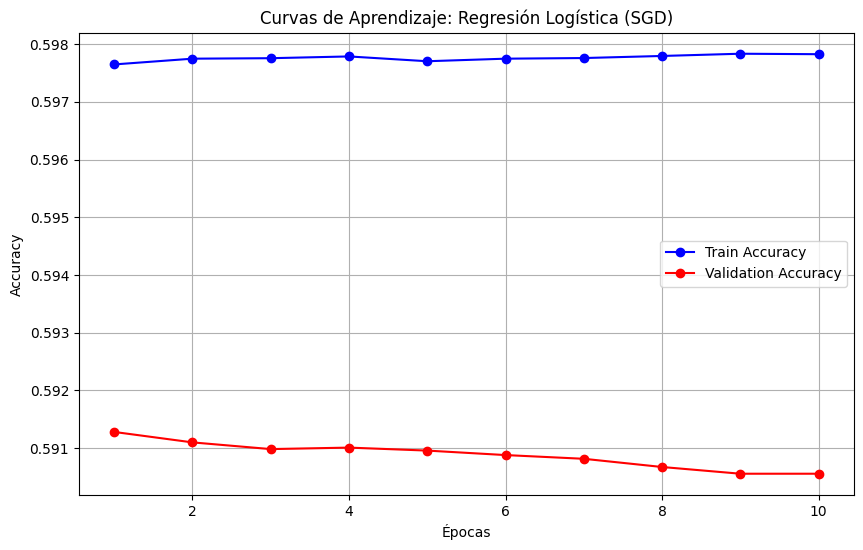

In [12]:
# 3. Ver gráficas
trainer.plot_training_curves()


--- Evaluación Final en TEST ---
              precision    recall  f1-score   support

     country       0.59      0.70      0.64     12888
        misc       0.72      0.71      0.71     12888
         pop       0.36      0.19      0.25     12888
         rap       0.75      0.79      0.77     12889
          rb       0.54      0.59      0.56     12888
        rock       0.47      0.56      0.51     12888

    accuracy                           0.59     77329
   macro avg       0.57      0.59      0.58     77329
weighted avg       0.57      0.59      0.58     77329



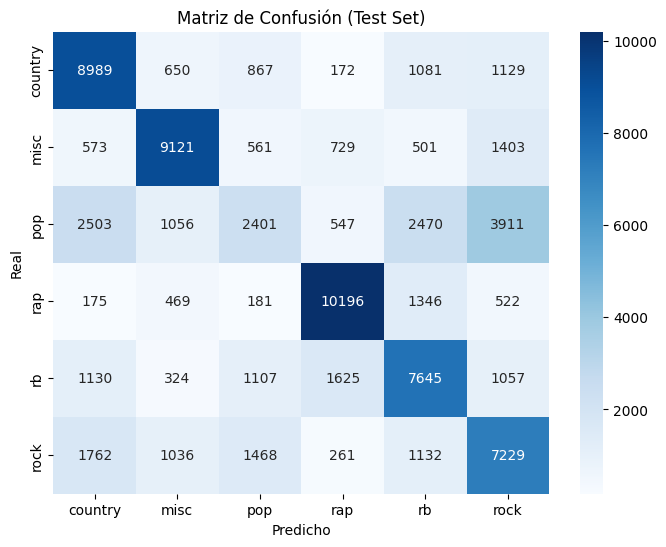

In [13]:
# 4. Evaluación final (Punto 9)
trainer.evaluate_final(id2label=dp.id2label)

## 3. Explicabilidad y Análisis de Errores

In [14]:
from src.analysis.error_analysis import ErrorAnalyzer
from sklearn.model_selection import train_test_split

# Recuperar X_test_raw si no está en el trainer (para sesiones antiguas)
if getattr(trainer, 'X_test_raw', None) is None:
    print("Reconstruyendo X_test_raw...")
    X = trainer.df['text']
    y = trainer.df['label']
    # Mismo split que en BaselineTrainer
    _, X_temp, _, y_temp = train_test_split(X, y, test_size=0.3, random_state=trainer.seed, stratify=y)
    _, X_test_raw, _, _ = train_test_split(X_temp, y_temp, test_size=0.5, random_state=trainer.seed, stratify=y_temp)
    trainer.X_test_raw = X_test_raw

# Inicializar Analizador
analyzer = ErrorAnalyzer(
    model=trainer.clf,
    vectorizer=trainer.vectorizer,
    X_test=trainer.X_test_vec,
    y_test=trainer.y_test,
    id2label=dp.id2label,
    df_test_raw=trainer.X_test_raw
)

Reconstruyendo X_test_raw...


### 3.1 Matriz de Confusión

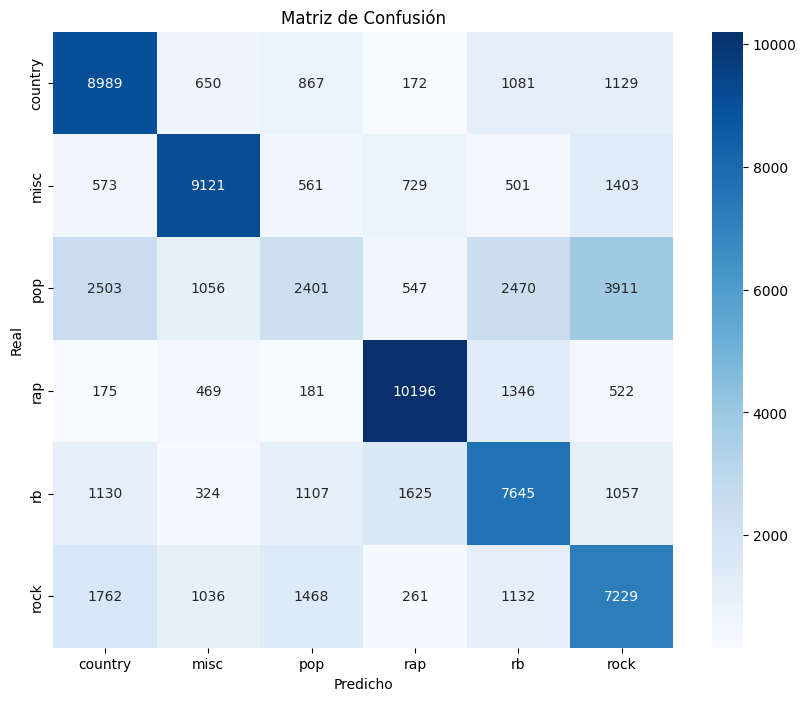

In [15]:
analyzer.plot_confusion_matrix()

### 3.2 Ejemplos Mal Clasificados

In [21]:
import pandas as pd

pd.set_option('display.max_colwidth', 200)
errors_df = analyzer.get_misclassified_examples(n=10)
errors_df

,text_snippet,true_label,pred_label,original_index
0,"I love you like a flower loves the sun\nAnd I need you like the earth needs the rain\nTogether we will walk on, straight through the fire\nAnd fuel our hearts with the flame\n\nI washed the blood ...",country,rock,42185
1,Jesus I will walk with you\nCompanion for the way\nMy constant friend and faithful guide\nBeside me every day\nThrough times of winter harsh and bare\nThrough summer’s gentle breeze\nI’ll walk wit...,pop,country,17351
2,\nToo many times that I’ve been here\nThere's nothing for me here\nIt's time for a change now\nSo if I pack my bags and never look back\nWould you come with me or would you stay now\nI remember ni...,rap,rb,24995
3,The Dutch talked of Antilles\nAs if it was Atlantis\nLonely & constant\nHave you had your fill of this?\n\nSing the Northwest Passage\nThe tidepools and the tundra\nFeel your way through the darkn...,country,misc,37114
4,"\n'Bout to take you out tonight baby\nLet's go\n\n\nNi igh igh igh ight\nThis is your ni igh igh igh ight\nIt's been a long week\nI know what you need, a little you and me\nYeah this is your ni ig...",country,rb,61538
5,"I stood by somebody else and then I stood by you\nI couldn't move my legs, I didn't know what to do\nI fail to find the words, I try hard to be cool\nI die to hear your voice, it's smoothly ringin...",pop,rock,42583
6,Sun's out Coffee filled Step out Embrace the bliss\nPainted red\nAnd your favourite smell Fresh And eloquent\nNow your dreams fill as you sit there still And the rays reflect your pale skin Now yo...,pop,rock,52283
7,😭Please I want my old username back. I promise I won´t make a mistake. I promise I won´t say something offensive. and I also promise that I won´t have to say anything bad. I Promise. Do you all fo...,misc,rock,20081
8,"\nTrue love come but once\nWhen it come yuh betta feel it\nFrom me did a wear one pants\nShe love me\nOne doubt, me no response\nDat gyal ya im deep in\nDis a no puppy love business\nMe a talk bou...",rap,rb,9664
9,When I was bored\nWhen I was bored\nI called for an alligator to entertain myself\nI ate a universe\nIt smiled and spit up a child\n\nOur child now makes rains and bows\nIt never stays in between ...,rock,misc,27085


### 3.3 Explicabilidad (Coeficientes del Modelo)
Analizamos qué palabras contribuyeron más a la predicción.

In [22]:
# Explicar el primer error encontrado (si existe)
if errors_df is not None and not errors_df.empty:
    idx_to_explain = errors_df.iloc[0]['original_index']
    analyzer.explain_prediction(idx_to_explain)
else:
    print("No hay errores para explicar, mostrando un ejemplo correcto aleatorio.")
    analyzer.explain_prediction(0)

--- Explicación para ejemplo 42185 ---
Predicho: rock | Real: country

Top palabras para clase PREDICHA (rock):
Palabra              Contribución TF-IDF     Coef      
-------------------------------------------------------
blood                0.1764       0.1035       1.7039
sun                  0.1054       0.1992       0.5292
ve                   0.0839       0.0609       1.3778
hands                0.0769       0.1590       0.4839
forgotten            0.0693       0.1432       0.4844
stand                0.0601       0.0992       0.6062
wake                 0.0594       0.1152       0.5160
blood hands          0.0338       0.2101       0.1608
fuel                 0.0229       0.1795       0.1277
past                 0.0224       0.1002       0.2239

Top palabras para clase REAL (country):
Palabra              Contribución TF-IDF     Coef      
-------------------------------------------------------
livin                0.2540       0.2350       1.0810
ve                   0.1290  

### 3.4 Análisis de Subgrupos (Longitud del Texto)

In [23]:
analyzer.analyze_subgroups()


--- Análisis de Error por Longitud de Texto ---
                  Total Muestras  Accuracy
length_group                              
Muy Corto (<500)            7143  0.471091
Corto (500-1k)             22125  0.510102
Medio (1k-2k)              31523  0.572534
Largo (2k-5k)              13217  0.732239
Muy Largo (>5k)             3321  0.964770


## 4. Modelado con Transformers (BERT/RoBERTa)

Implementamos un modelo basado en Transformers para capturar mejor la semántica profunda.
Usaremos `roberta-base` con la librería `transformers` de HuggingFace.

In [1]:
from src.models.transformer_model import TransformerTrainer

# Inicializar el trainer con RoBERTa
# Nota: Se puede cambiar a 'bert-base-uncased' u otros
tf_trainer = TransformerTrainer(model_name='roberta-base', num_labels=6, seed=42)

ModuleNotFoundError: No module named 'torch'

In [ ]:
# Preparar datos (Tokenización)
# Usamos el mismo DataFrame que ya tenemos cargado en 'dp'
tf_trainer.prepare_data(dp.get_df())

In [ ]:
# Entrenar el modelo
# Ajustar epochs y batch_size según la capacidad de la máquina
tf_trainer.train(epochs=3, batch_size=16)

In [ ]:
# Evaluación final
tf_trainer.evaluate()